# Correlation in Climate Data
## What it is, what it isn't, and how to calculate it

---

## What is Correlation?

Imagine you notice that in months when it rains a lot in your town, it also tends to be cooler. And in months with little rain, it tends to be warmer. There seems to be a **relationship** between temperature and precipitation. But how strong is that relationship? Is it consistent?

**Correlation** is a statistical measure that tells you:
1. **Whether** two variables tend to move together
2. **How strongly** they move together
3. **In what direction** — do they move in the same direction, or opposite directions?

The most common measure is the **Pearson correlation coefficient**, denoted $r$:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \cdot \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

The result $r$ always falls between **−1 and +1**:

| Value of $r$ | Meaning |
|---|---|
| $r = +1$ | Perfect positive correlation — as one goes up, the other always goes up |
| $r = 0$ | No linear relationship |
| $r = -1$ | Perfect negative correlation — as one goes up, the other always goes down |
| $|r| > 0.7$ | Strong correlation |
| $0.4 < |r| \leq 0.7$ | Moderate correlation |
| $|r| \leq 0.4$ | Weak correlation |

---

## ⚠️ Correlation Does NOT Mean Causation

This is perhaps the single most important lesson in statistics.

**Just because two things are correlated does not mean one causes the other.**

Some classic examples of spurious (misleading) correlations:
- Ice cream sales and drowning rates are strongly correlated. Does ice cream cause drowning? Of course not — both are caused by a third factor: **hot summer weather**.
- Nicolas Cage films per year correlates with swimming pool drownings. Clearly coincidence.
- In climate science: CO₂ and global temperature are correlated over centuries — and in this case, there *is* a well-understood physical mechanism linking them. But the correlation alone doesn't prove causation; you need the physical reasoning too.

When you find a correlation, always ask:
1. Is there a **physical mechanism** that could explain this relationship?
2. Could both variables be driven by a **third, hidden variable**?
3. Could this be **coincidence** — especially with short datasets?

**Correlation is a starting point for investigation, not a conclusion.**

---

## Setting Up: Generate a Synthetic Dataset

We'll create 20 years of **monthly average temperature** and **monthly total precipitation** for an imaginary town called **Millbrook, WI** — a fictitious mid-continent location with cold winters and warm, occasionally wet summers.

The data is designed so that:
- Both variables have realistic seasonal cycles
- There is a moderate **negative correlation** between temperature and precipitation (winters are cold and dry; shoulder seasons bring more precipitation)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

rng = np.random.default_rng(seed=7)

# --- Generate synthetic monthly data ---
n_years = 20
start = '2002-01-01'
dates = pd.date_range(start=start, periods=n_years * 12, freq='MS')  # Month Start
n = len(dates)

months = dates.month.values

# Temperature (°C): cold winter, warm summer, mid-continent style
# Jan mean ~ -6°C, July mean ~ 22°C
temp_seasonal = -6.0 + 14.0 * np.cos(np.pi * (months - 7) / 6)
temp_noise = rng.normal(0, 2.0, n)
temperature = temp_seasonal + temp_noise

# Precipitation (mm): peak in May-June, dry in winter
# Seasonal cycle peaks around month 5 (May)
precip_seasonal = 55 + 35 * np.cos(np.pi * (months - 5) / 6)
precip_seasonal = np.clip(precip_seasonal, 5, None)  # no negative precip

# Add anti-correlated noise component (makes r ~ -0.45)
shared_noise = rng.normal(0, 1.0, n)
precip_noise = rng.normal(0, 12.0, n) - 6.0 * shared_noise
temp_noise_extra = 0.8 * shared_noise + rng.normal(0, 1.0, n)

temperature = temp_seasonal + temp_noise + temp_noise_extra
precipitation = np.clip(precip_seasonal + precip_noise, 0, None)

# Build DataFrame
df = pd.DataFrame({
    'date': dates,
    'year': dates.year,
    'month': months,
    'temperature_C': temperature,
    'precip_mm': precipitation
})

print(f"Dataset: {len(df)} monthly observations ({df['year'].min()}–{df['year'].max()})")
print(f"Temperature: {df['temperature_C'].min():.1f}°C to {df['temperature_C'].max():.1f}°C")
print(f"Precipitation: {df['precip_mm'].min():.1f} mm to {df['precip_mm'].max():.1f} mm")
df.head()

Dataset: 240 monthly observations (2002–2021)
Temperature: -22.9°C to 13.6°C
Precipitation: 0.0 mm to 124.4 mm


,date,year,month,temperature_C,precip_mm
0,2002-01-01,2002,1,-20.970205,43.188363
1,2002-02-01,2002,2,-17.273881,50.168222
2,2002-03-01,2002,3,-15.923779,74.914411
3,2002-04-01,2002,4,-6.499393,85.420801
4,2002-05-01,2002,5,0.111431,114.642905


---
## Step 1: Visualize the Two Timeseries

Before computing any statistics, always **look at your data**. Let's plot both variables over the full 20-year record.

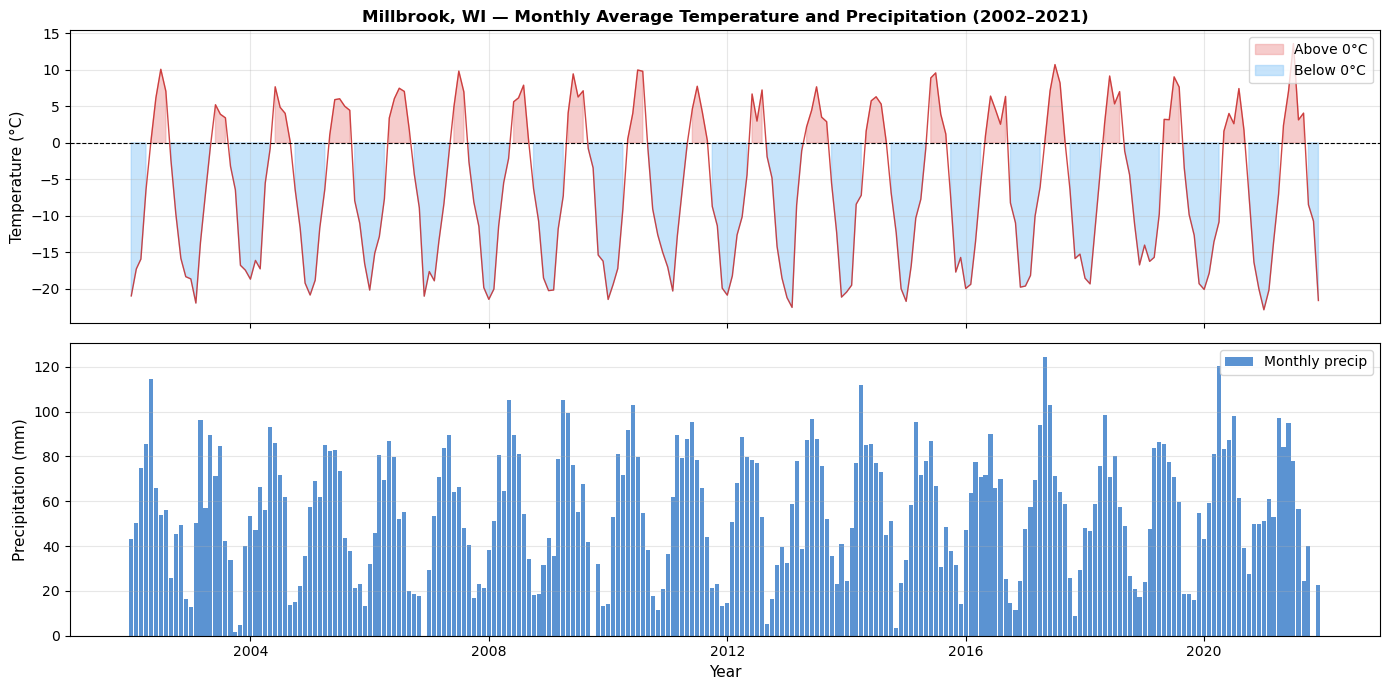

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Temperature
ax1.plot(df['date'], df['temperature_C'], color='#C62828', linewidth=1.0, alpha=0.85)
ax1.fill_between(df['date'], df['temperature_C'], where=df['temperature_C'] >= 0,
                 color='#EF9A9A', alpha=0.5, label='Above 0°C')
ax1.fill_between(df['date'], df['temperature_C'], where=df['temperature_C'] < 0,
                 color='#90CAF9', alpha=0.5, label='Below 0°C')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.set_title('Millbrook, WI — Monthly Average Temperature and Precipitation (2002–2021)',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Precipitation
ax2.bar(df['date'], df['precip_mm'], color='#1565C0', alpha=0.7, width=25, label='Monthly precip')
ax2.set_ylabel('Precipitation (mm)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.legend(loc='upper right')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 2: Compute the Pearson Correlation Coefficient

Now let's calculate $r$ using three different methods to show they all give the same answer.

In [3]:
T = df['temperature_C'].values
P = df['precip_mm'].values

# --- Method 1: Manual calculation using the formula ---
T_bar, P_bar = T.mean(), P.mean()
numerator = np.sum((T - T_bar) * (P - P_bar))
denominator = np.sqrt(np.sum((T - T_bar)**2) * np.sum((P - P_bar)**2))
r_manual = numerator / denominator

# --- Method 2: NumPy ---
r_numpy = np.corrcoef(T, P)[0, 1]

# --- Method 3: SciPy (also gives p-value) ---
r_scipy, p_value = stats.pearsonr(T, P)

print("Pearson Correlation Coefficient (r)")
print("=====================================")
print(f"  Manual calculation : r = {r_manual:.4f}")
print(f"  NumPy corrcoef     : r = {r_numpy:.4f}")
print(f"  SciPy pearsonr     : r = {r_scipy:.4f}  (p-value = {p_value:.2e})")
print()

# Interpret the result
if abs(r_scipy) > 0.7:
    strength = 'strong'
elif abs(r_scipy) > 0.4:
    strength = 'moderate'
else:
    strength = 'weak'

direction = 'positive' if r_scipy > 0 else 'negative'
print(f"Interpretation: {strength} {direction} correlation")
print()
if p_value < 0.05:
    print(f"The p-value ({p_value:.2e}) is less than 0.05, so this correlation")
    print("is statistically significant — unlikely to be due to chance alone.")
else:
    print(f"The p-value ({p_value:.2e}) is greater than 0.05; not statistically significant.")

Pearson Correlation Coefficient (r)
  Manual calculation : r = 0.4215
  NumPy corrcoef     : r = 0.4215
  SciPy pearsonr     : r = 0.4215  (p-value = 9.42e-12)

Interpretation: moderate positive correlation

The p-value (9.42e-12) is less than 0.05, so this correlation
is statistically significant — unlikely to be due to chance alone.


---
## Step 3: Visualize the Correlation — Scatter Plot

A **scatter plot** is the classic way to visualize a correlation. Each point represents one month. If there's a relationship, the points will form a pattern rather than a random cloud.

/var/folders/hg/by60chbx3gv__xtd5c1p9sxm0000gn/T/ipykernel_40827/3250255537.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('twilight', 12)


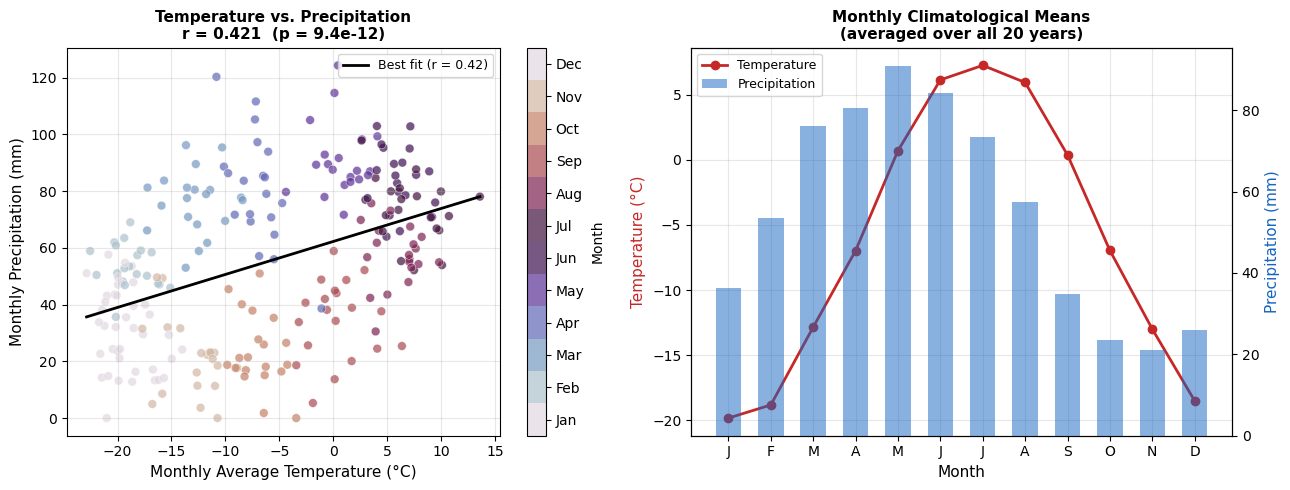

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: scatter plot colored by month ---
cmap = plt.cm.get_cmap('twilight', 12)
sc = axes[0].scatter(df['temperature_C'], df['precip_mm'],
                     c=df['month'], cmap=cmap, vmin=0.5, vmax=12.5,
                     alpha=0.7, s=40, edgecolors='white', linewidths=0.4)

# Add regression line
slope, intercept, _, _, _ = stats.linregress(T, P)
x_line = np.linspace(T.min(), T.max(), 100)
axes[0].plot(x_line, slope * x_line + intercept, color='black', linewidth=2, label=f'Best fit (r = {r_scipy:.2f})')

cbar = plt.colorbar(sc, ax=axes[0], ticks=range(1, 13))
cbar.set_ticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
cbar.set_label('Month')

axes[0].set_xlabel('Monthly Average Temperature (°C)', fontsize=11)
axes[0].set_ylabel('Monthly Precipitation (mm)', fontsize=11)
axes[0].set_title(f'Temperature vs. Precipitation\nr = {r_scipy:.3f}  (p = {p_value:.1e})', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Right: monthly climatological means to show the seasonal pattern ---
monthly_mean = df.groupby('month')[['temperature_C', 'precip_mm']].mean()
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

ax_t = axes[1]
ax_p = ax_t.twinx()

ax_t.plot(monthly_mean.index, monthly_mean['temperature_C'],
          color='#C62828', marker='o', linewidth=2, label='Temperature')
ax_p.bar(monthly_mean.index, monthly_mean['precip_mm'],
         color='#1565C0', alpha=0.5, width=0.6, label='Precipitation')

ax_t.set_xlabel('Month', fontsize=11)
ax_t.set_ylabel('Temperature (°C)', color='#C62828', fontsize=11)
ax_p.set_ylabel('Precipitation (mm)', color='#1565C0', fontsize=11)
ax_t.set_xticks(range(1, 13))
ax_t.set_xticklabels(month_labels)
ax_t.set_title('Monthly Climatological Means\n(averaged over all 20 years)', fontsize=11, fontweight='bold')
ax_t.grid(True, alpha=0.3)

lines1, labels1 = ax_t.get_legend_handles_labels()
lines2, labels2 = ax_p.get_legend_handles_labels()
ax_t.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## Step 4: Month-by-Month Correlation

The correlation we computed above mixes all months together — and a lot of that signal comes from the seasonal cycle (both temperature and precipitation vary seasonally). 

A more rigorous approach is to compute the correlation **within each month** across the 20 years — this removes the seasonal cycle and tests whether, e.g., warmer-than-average Julys also tend to be wetter or drier.

This is called a **within-season** or **anomaly correlation**.

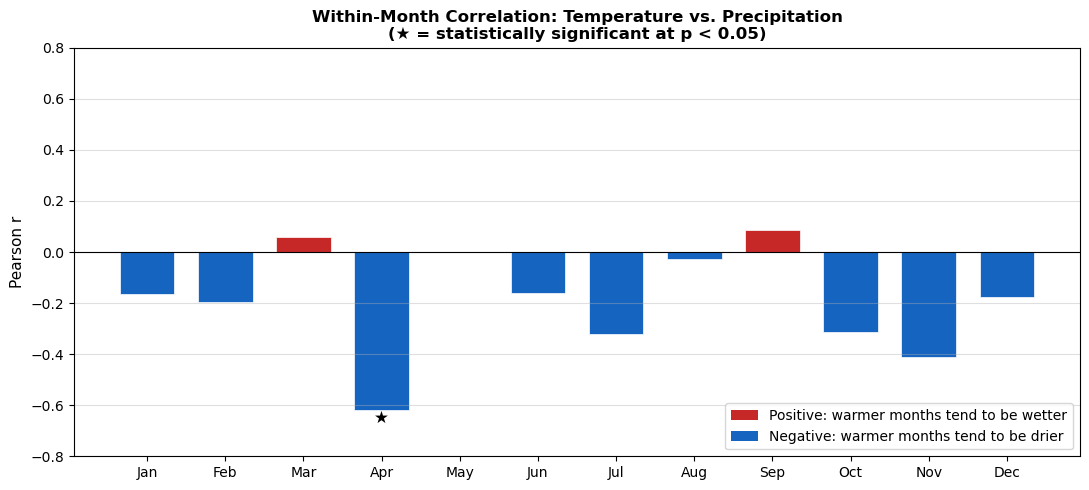

Within-month correlations:
  Jan: r = -0.164, p = 0.490  
  Feb: r = -0.197, p = 0.406  
  Mar: r = +0.059, p = 0.804  
  Apr: r = -0.618, p = 0.004  (significant)
  May: r = -0.001, p = 0.998  
  Jun: r = -0.161, p = 0.498  
  Jul: r = -0.321, p = 0.168  
  Aug: r = -0.027, p = 0.909  
  Sep: r = +0.087, p = 0.716  
  Oct: r = -0.313, p = 0.179  
  Nov: r = -0.411, p = 0.072  
  Dec: r = -0.178, p = 0.454  


In [5]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
r_by_month = []
p_by_month = []

for m in range(1, 13):
    sub = df[df['month'] == m]
    r, p = stats.pearsonr(sub['temperature_C'], sub['precip_mm'])
    r_by_month.append(r)
    p_by_month.append(p)

r_by_month = np.array(r_by_month)
p_by_month = np.array(p_by_month)

fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#C62828' if r > 0 else '#1565C0' for r in r_by_month]
bars = ax.bar(range(1, 13), r_by_month, color=colors, edgecolor='white', linewidth=0.5, width=0.7)

# Mark statistically significant months (p < 0.05) with a star
for i, (r, p) in enumerate(zip(r_by_month, p_by_month)):
    if p < 0.05:
        y_pos = r + (0.02 if r >= 0 else -0.05)
        ax.text(i + 1, y_pos, '★', ha='center', fontsize=12,
                color='black', fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylim(-0.8, 0.8)
ax.set_ylabel('Pearson r', fontsize=11)
ax.set_title('Within-Month Correlation: Temperature vs. Precipitation\n(★ = statistically significant at p < 0.05)',
             fontsize=12, fontweight='bold')
ax.grid(True, axis='y', alpha=0.4)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C62828', label='Positive: warmer months tend to be wetter'),
                   Patch(facecolor='#1565C0', label='Negative: warmer months tend to be drier')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("Within-month correlations:")
for m, (r, p) in enumerate(zip(r_by_month, p_by_month), start=1):
    sig = '(significant)' if p < 0.05 else ''
    print(f"  {month_names[m-1]}: r = {r:+.3f}, p = {p:.3f}  {sig}")

---
## Step 5: Correlation Matrix

When you have many variables, a **correlation matrix** gives you an at-a-glance view of all pairwise correlations. Here we'll show a simple 2×2 matrix for our two variables, but this technique scales to dozens of variables.

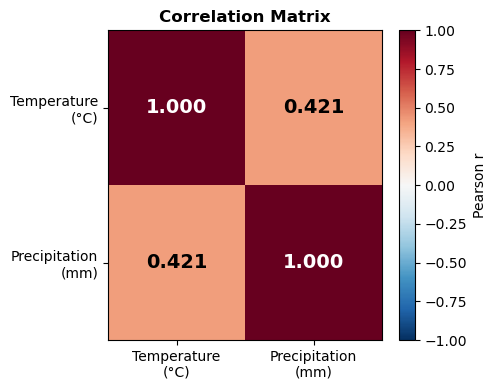

In [6]:
corr_matrix = df[['temperature_C', 'precip_mm']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')

labels = ['Temperature\n(°C)', 'Precipitation\n(mm)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.3f}',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if abs(corr_matrix.values[i, j]) > 0.5 else 'black')

ax.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

| Step | What we did |
|------|-------------|
| 1 | Visualized both timeseries to get a feel for the data |
| 2 | Computed the Pearson $r$ using three equivalent methods |
| 3 | Used a scatter plot to visualize the relationship |
| 4 | Computed **within-month** correlations to remove seasonal cycle bias |
| 5 | Displayed a correlation matrix |

**Key takeaways:**
- The Pearson correlation coefficient $r$ ranges from −1 to +1.
- A negative $r$ means that as one variable increases, the other tends to decrease.
- Always check **statistical significance** (p-value) — with short records, even moderate correlations can occur by chance.
- **Always remember: correlation ≠ causation.** A correlation is a starting point, not an explanation. Physical understanding of the system is essential.
- Removing the seasonal cycle before computing correlations ("anomaly correlation") can reveal more meaningful relationships within a season.